Matplotlib is building the font cache; this may take a moment.


Integrated squared error over x
GFR: 0.0046
NW : 0.0423


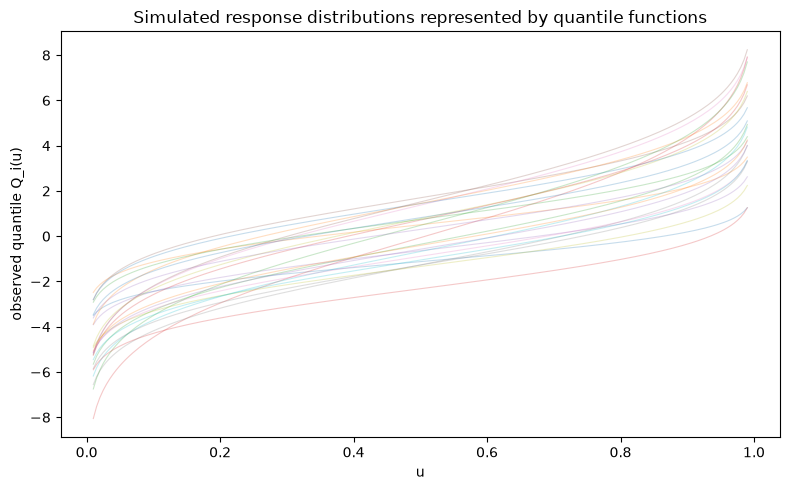

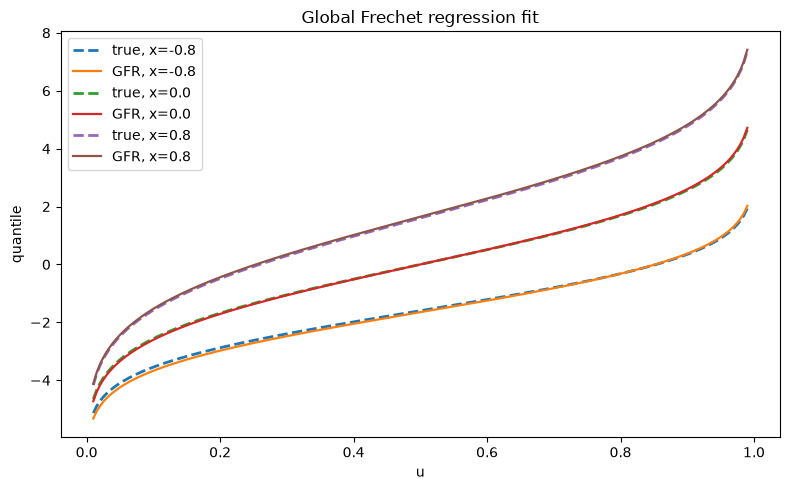

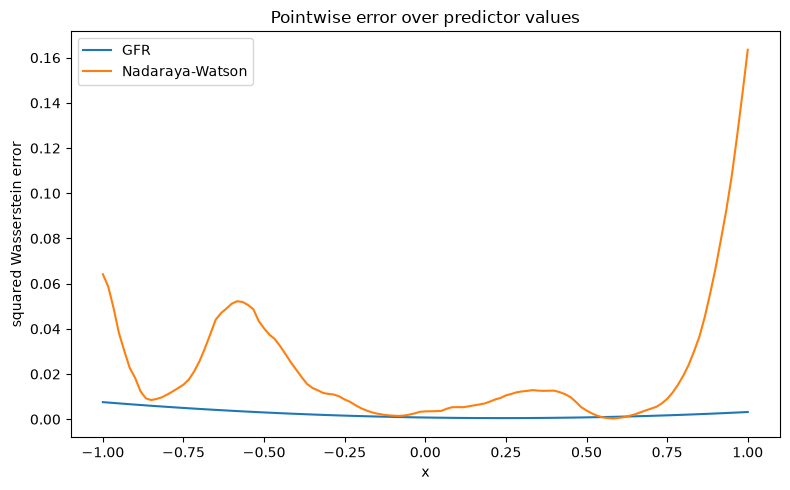

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ============================================================
# 0. 単調増加関数への射影
#    Wasserstein 空間では quantile function は単調増加である必要がある。
#    weighted average が単調性を壊す場合に備えて PAVA で補正する。
# ============================================================

def pava_increasing(y):
    """
    y を単調非減少列へ L2 射影する。
    equal weights の Pool Adjacent Violators Algorithm。
    """
    y = np.asarray(y, dtype=float)

    levels = []
    weights = []
    starts = []
    ends = []

    for i, val in enumerate(y):
        levels.append(float(val))
        weights.append(1.0)
        starts.append(i)
        ends.append(i)

        while len(levels) >= 2 and levels[-2] > levels[-1]:
            w = weights[-2] + weights[-1]
            lvl = (weights[-2] * levels[-2] + weights[-1] * levels[-1]) / w

            levels[-2] = lvl
            weights[-2] = w
            ends[-2] = ends[-1]

            levels.pop()
            weights.pop()
            starts.pop()
            ends.pop()

    out = np.empty_like(y, dtype=float)
    for lvl, st, en in zip(levels, starts, ends):
        out[st:en + 1] = lvl

    return out


# ============================================================
# 1. データ生成
#    X_i は実数値 predictor。
#    Y_i は確率分布。ここでは正規分布として生成し、
#    quantile function Q_i(u) = mu_i + sigma_i Phi^{-1}(u)
#    で保持する。
# ============================================================

rng = np.random.default_rng(2026)

n = 80
X = rng.uniform(-1.0, 1.0, size=n)

# 真の conditional Fréchet mean のパラメータ
mu0, beta = 0.0, 2.0
sigma0, gamma = 2.0, 0.6

# 観測分布のばらつき
v_mu = 0.35**2
v_sigma = 0.20

# E[mu_i | X_i = x] = mu0 + beta x
mu = mu0 + beta * X + rng.normal(0.0, np.sqrt(v_mu), size=n)

# E[sigma_i | X_i = x] = sigma0 + gamma x
# Gamma 分布で正の sigma を生成する。
sigma_mean = sigma0 + gamma * X
shape = sigma_mean**2 / v_sigma
scale = v_sigma / sigma_mean
sigma = rng.gamma(shape=shape, scale=scale)

# quantile grid
u = np.linspace(0.01, 0.99, 200)
z = norm.ppf(u)

# 各観測分布 Y_i の quantile function
Q = mu[:, None] + sigma[:, None] * z[None, :]


def true_quantile(x):
    """
    真の conditional Fréchet mean distribution の quantile function。
    """
    return mu0 + beta * x + (sigma0 + gamma * x) * z


def wasserstein2(q1, q2):
    """
    1次元分布間の squared 2-Wasserstein distance。
    quantile functions の L2 distance として計算する。
    """
    return np.trapezoid((q1 - q2)**2, u)


# ============================================================
# 2. Global Fréchet regression
# ============================================================

def gfr_quantile(x):
    """
    global Fréchet regression estimator at predictor value x.

    p = 1 の場合：
        s_i(x) = 1 + (X_i - Xbar)(x - Xbar) / Varhat(X)

    推定 quantile:
        Qhat_x = n^{-1} sum_i s_i(x) Q_i
    """
    xbar = X.mean()
    varx = np.mean((X - xbar)**2)

    if varx <= 0:
        raise ValueError("X の標本分散が 0 です。")

    s = 1.0 + (X - xbar) * (x - xbar) / varx

    # weighted Fréchet mean in Wasserstein space
    q = np.mean(s[:, None] * Q, axis=0)

    # quantile function であるための単調性を保証
    q = pava_increasing(q)

    return q


# ============================================================
# 3. 比較用：Nadaraya-Watson 型 Fréchet smoother
#    非負 kernel weight による局所 Fréchet mean。
#    これは global Fréchet regression ではないが、比較対象として置く。
# ============================================================

def epanechnikov(t):
    out = 0.75 * (1.0 - t**2)
    out[np.abs(t) > 1.0] = 0.0
    return out


def nw_quantile(x, h=0.35):
    """
    Nadaraya-Watson 型の Wasserstein Fréchet smoother。
    """
    w = epanechnikov((X - x) / h)

    if w.sum() <= 0:
        # kernel window にデータがない場合の保険
        j = np.argmin(np.abs(X - x))
        return Q[j].copy()

    q = np.sum(w[:, None] * Q, axis=0) / w.sum()
    q = pava_increasing(q)

    return q


# ============================================================
# 4. 推定結果を見る
# ============================================================

x_grid = np.linspace(-1.0, 1.0, 121)

gfr_err = []
nw_err = []

for x in x_grid:
    q_true = true_quantile(x)
    q_gfr = gfr_quantile(x)
    q_nw = nw_quantile(x, h=0.35)

    gfr_err.append(wasserstein2(q_gfr, q_true))
    nw_err.append(wasserstein2(q_nw, q_true))

gfr_ise = np.trapezoid(gfr_err, x_grid)
nw_ise = np.trapezoid(nw_err, x_grid)

print("Integrated squared error over x")
print(f"GFR: {gfr_ise:.4f}")
print(f"NW : {nw_ise:.4f}")


# ============================================================
# 5. 可視化
# ============================================================

# 観測された response distributions
plt.figure(figsize=(8, 5))
for i in range(min(n, 25)):
    plt.plot(u, Q[i], alpha=0.25, linewidth=0.8)
plt.xlabel("u")
plt.ylabel("observed quantile Q_i(u)")
plt.title("Simulated response distributions represented by quantile functions")
plt.tight_layout()


# x = -0.8, 0, 0.8 における真値と GFR 推定値
x_show = [-0.8, 0.0, 0.8]

plt.figure(figsize=(8, 5))
for x in x_show:
    plt.plot(u, true_quantile(x), linestyle="--", linewidth=2, label=f"true, x={x}")
    plt.plot(u, gfr_quantile(x), linewidth=1.6, label=f"GFR, x={x}")

plt.xlabel("u")
plt.ylabel("quantile")
plt.title("Global Frechet regression fit")
plt.legend()
plt.tight_layout()


# predictor x ごとの Wasserstein error
plt.figure(figsize=(8, 5))
plt.plot(x_grid, gfr_err, label="GFR")
plt.plot(x_grid, nw_err, label="Nadaraya-Watson")
plt.xlabel("x")
plt.ylabel("squared Wasserstein error")
plt.title("Pointwise error over predictor values")
plt.legend()
plt.tight_layout()

plt.show()